# 🌲 Sensibilité au volume de CSV — RF/GB (structure IDENTIQUE au sweep PatchTST)
## Consigne Dr. Sarun (Training Procedure -> Best Score, point 3)
### CMKL University · Stage 2026

---

**Correction méthodologique importante** : ce notebook reproduit EXACTEMENT la
même structure que le sweep de sensibilité PatchTST (modèle mixte) — pas une
version simplifiée CSV seul.

```
Train = .npy COMPLET (17100, inchangé)  +  CSV à fraction variable
Test  = .npy officiel (18000, FIXE)  ET  CSV (280, FIXE) — évalués SÉPARÉMENT
```

**Même comparaison, même paramètre, même seed** que PatchTST — pour une
superposition directe des deux courbes (npy et CSV) entre les deux familles
de modèles.

**Résultats PatchTST déjà obtenus (référence)** :
```
Fraction   CSV Train   Test .npy   Test CSV
1.00       1864        95.03%      98.50%
0.70       1304        94.71%      98.00%
0.43        801        94.92%      97.75%
0.14        260        94.63%      92.25%
0.07        130        94.85%      81.25%
```

**Un seul paramètre à changer entre chaque run** :
```python
CSV_TRAIN_FRACTION = 1.0   # puis 0.7, 0.43, 0.14, 0.07 — mêmes valeurs que PatchTST
```


---
## ⚙️ Section 0 — Installation & Imports


In [37]:
import subprocess, sys
def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
for pkg in ['scikit-learn', 'xgboost', 'lightgbm', 'seaborn']:
    try: __import__(pkg.replace('-','_'))
    except ImportError: install(pkg)
print('✓ Packages prêts')

✓ Packages prêts


In [38]:
import os, glob, re, io, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import xgboost as xgb
import lightgbm as lgb

SEED = 42
np.random.seed(SEED)
HOME = os.path.expanduser('~')
print(f'HOME = {HOME}')

HOME = /home/glider


In [39]:
# ════════════════════════════════════════════════════════════════════
# 🎛️  PARAMÈTRE À CHANGER ENTRE CHAQUE RUN — mêmes valeurs que le sweep PatchTST
# ════════════════════════════════════════════════════════════════════
CSV_TRAIN_FRACTION = 0.07    # ← MODIFIE UNIQUEMENT CETTE LIGNE
#   1.0   → ≈1864 spectres CSV train    0.43  → ≈801 spectres
#   0.7   → ≈1304 spectres              0.14  → ≈260 spectres
#                                        0.07  → ≈130 spectres
# ════════════════════════════════════════════════════════════════════

RUN_LABEL = f'rfgb_mixed_csvfrac{int(CSV_TRAIN_FRACTION*100)}'
print(f'🎛️  Run actuel : {RUN_LABEL}  (CSV_TRAIN_FRACTION = {CSV_TRAIN_FRACTION})')

🎛️  Run actuel : rfgb_mixed_csvfrac7  (CSV_TRAIN_FRACTION = 0.07)


In [40]:
WN_GRID = np.arange(650, 4000, 0.5)   # 6700 points, grille commune npy+CSV
L = len(WN_GRID)

ASSUMED_CLASSES = [
    'ABS', 'ACRYLIC', 'CELLULOSE', 'CHITOSAN', 'ENR', 'EPDM', 'EVA', 'HDPE',
    'LDPE', 'NYLON', 'PBAT', 'PBS', 'PC', 'PEEK', 'PEI', 'PET',
    'PF THERMOPLASTIC', 'PF THERMOSET', 'PHB', 'PLA', 'PMMA', 'POM', 'PP',
    'PS', 'PTFE', 'PU', 'PVA', 'PVC', 'PVDF', 'SAN',
]
N_CLASSES = len(ASSUMED_CLASSES)
le = LabelEncoder()
le.fit(ASSUMED_CLASSES)
print(f'{N_CLASSES} classes, grille {L} points')

30 classes, grille 6700 points


---
## 📊 Section 1 — Données .npy (TOUJOURS COMPLÈTES, comme dans le sweep PatchTST)


In [41]:
NPY_ROOT  = os.path.join(HOME, 'data', '2026-FTIR-Preprocesed','2026 - FTIR - 4. Selected Datasets - Preprocessed')
TRAIN_DIR = os.path.join(NPY_ROOT, '1.1 TrainingSet - UptoY dB')
TEST_DIR  = os.path.join(NPY_ROOT, '1.2 TestSet - UptoY dB')

def npy_path(base_dir, filename):
    p = os.path.join(base_dir, filename)
    if not os.path.exists(p): print(f'  ✗ INTROUVABLE : {p}')
    return p

noise = 'Upto30SNR'
npy_train_clean = np.load(npy_path(TRAIN_DIR, 'TrainGroundTruthSet_Pre.npy'))
npy_train_noisy = np.load(npy_path(TRAIN_DIR, f'TrainNoisySet_{noise}_Pre.npy'))
npy_test_clean  = np.load(npy_path(TEST_DIR,  'TestGroundTruthSet_Pre.npy'))
npy_test_noisy  = np.load(npy_path(TEST_DIR,  f'TestNoisySet_{noise}_Pre.npy'))

assert npy_train_clean.shape[1] == L
N_PER_CLASS_NPY_TRAIN = npy_train_clean.shape[0] // N_CLASSES
N_PER_CLASS_NPY_TEST  = npy_test_clean.shape[0]  // N_CLASSES
npy_labels_train_full = np.repeat(np.arange(N_CLASSES), N_PER_CLASS_NPY_TRAIN)
npy_labels_test       = np.repeat(np.arange(N_CLASSES), N_PER_CLASS_NPY_TEST)

# ── Réserver le même val set que PatchTST (30/classe) pour un volume train
# EFFECTIF identique (17100), même si RF/GB n'utilise pas de val à proprement parler
N_VAL_PER_CLASS_NPY = 30
val_idx_npy, train_idx_npy = [], []
for c in range(N_CLASSES):
    cls_idx = np.where(npy_labels_train_full == c)[0]
    rng = np.random.RandomState(SEED)
    rng.shuffle(cls_idx)
    val_idx_npy.extend(cls_idx[:N_VAL_PER_CLASS_NPY])
    train_idx_npy.extend(cls_idx[N_VAL_PER_CLASS_NPY:])
train_idx_npy = np.array(train_idx_npy)

npy_train_noisy_eff = npy_train_noisy[train_idx_npy]
npy_labels_train_eff = npy_labels_train_full[train_idx_npy]

print(f'✓ .npy Train effectif : {npy_train_noisy_eff.shape[0]} spectres (identique au sweep PatchTST)')
print(f'✓ .npy Test officiel  : {npy_test_noisy.shape[0]} spectres (FIXE)')

✓ .npy Train effectif : 17100 spectres (identique au sweep PatchTST)
✓ .npy Test officiel  : 18000 spectres (FIXE)


---
## 📁 Section 2 — Données CSV (fraction variable, MÊME seed que PatchTST)


In [42]:
CSV_ROOT = os.path.join(HOME, 'data', '2026-FirstDataSet', '2026 - Complete FTIR Dataset')

PATHS_CSV = {
    '2023_base' : os.path.join(CSV_ROOT, '2023 Dataset - 22 MP Types with 10 Clean and 60 Noisy'),
    '2025_ext'  : os.path.join(CSV_ROOT, '2025 Dataset 1 - Same 22 MP Types - Add 40 Spectra'),
    '2025_new'  : os.path.join(CSV_ROOT, '2025 Dataset 2 - New 9 MP Types - 50 Clean and 100 Noisy'),
}
for name, path in PATHS_CSV.items():
    status = '✓' if os.path.exists(path) else '✗ INTROUVABLE'
    print(f'  {status}  {name}')

  ✓  2023_base
  ✓  2025_ext
  ✓  2025_new


In [43]:
EXCLUDE_FILES = {'ref.csv', 'reference.csv', 'background.csv', 'bg.csv'}

def is_noisy_csv(filepath):
    p = str(filepath).lower()
    if any(k in p for k in ['noisy', '_sd', '-sd', 'sd_']): return True
    if any(k in p for k in ['clean', '_rm', '-rm', 'rm_']): return False
    return False

def extract_label_csv(filepath):
    name = Path(filepath).stem.upper()
    for pattern in ['_SD_', '_RM_', '_NOISY', '_CLEAN', 'PARTICLE', '-NOISY',
                    '-CLEAN', '_50', '_60', '_40', '_100', '_10', '_30',
                    ' SPECTRUMS', ' SPECTUMS', 'ADD_40', '-ADD_40']:
        name = name.replace(pattern, ' ')
    name = re.sub(r'\d+', '', name)
    name = re.sub(r'\bNEW\b|\bJAN\b|\bX\b', '', name)
    name = ' '.join(name.replace('_', ' ').replace('-', ' ').split())
    MAPPING = {
        'NYLON PARTICLE' : 'NYLON', 'PTEE' : 'PTFE', 'PTFE' : 'PTFE',
        'PF THERMOPLASTIC CLEAN' : 'PF THERMOPLASTIC',
        'PF THERMOSET CLEAN'     : 'PF THERMOSET',
    }
    if name in MAPPING: return MAPPING[name]
    if name in ASSUMED_CLASSES: return name
    for cls in ASSUMED_CLASSES:
        if cls in name or name in cls: return cls
    return None

def read_csv_multispectra(filepath, sep=','):
    try:
        with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
            lines = f.readlines()
        start_idx = 0
        for i, line in enumerate(lines):
            parts = line.strip().split(sep)
            if len(parts) >= 2:
                try:
                    float(parts[0].replace(',', '.'))
                    start_idx = i; break
                except ValueError: continue
        valid = ''.join(lines[start_idx:])
        headers = lines[start_idx-1].strip().split(sep) if start_idx > 0 else []
        try:
            df = pd.read_csv(io.StringIO(valid), sep=sep, header=None, decimal=',')
        except Exception:
            df = pd.read_csv(io.StringIO(valid), sep=sep, header=None, decimal='.')
        cols = []
        for ci, cn in enumerate(df.columns):
            h = headers[ci].upper() if ci < len(headers) else ''
            v = str(df[cn].iloc[0]).upper()
            if any(k in h for k in ['AIR','BACKGROUND','BG']): continue
            if any(k in v for k in ['AIR','BACKGROUND','BG']): continue
            cols.append(cn)
        df = df[cols].apply(pd.to_numeric, errors='coerce')
        df = df.dropna(subset=[df.columns[0]])
        if len(df) < 100: return None
        wn    = df.iloc[:, 0].values.astype(float)
        order = np.argsort(wn); wn = wn[order]
        spectra = []
        for c in range(1, df.shape[1]):
            ab = df.iloc[order, c].values.astype(float)
            if np.isnan(ab).all() or ab.std() < 1e-10: continue
            nans = np.isnan(ab)
            if nans.any():
                ab[nans] = np.interp(np.where(nans)[0], np.where(~nans)[0], ab[~nans])
            spectra.append(ab.astype(np.float32))
        return (wn, spectra) if spectra else None
    except Exception: return None

print('✓ Fonctions de lecture définies')

✓ Fonctions de lecture définies


In [44]:
print('Chargement des CSV bruités...')
csv_records = []
for src_name, folder in PATHS_CSV.items():
    if not os.path.exists(folder): continue
    files = glob.glob(os.path.join(folder, '**/*.csv'), recursive=True)
    n_ok = 0
    for fp in files:
        if Path(fp).name.lower() in EXCLUDE_FILES: continue
        label = extract_label_csv(fp)
        if label is None: continue
        result = read_csv_multispectra(fp)
        if result is None: continue
        wn, spectra_list = result
        noisy = is_noisy_csv(fp)
        if not noisy: continue
        for sp in spectra_list:
            sp_interp = np.interp(WN_GRID, wn, sp).astype(np.float32)
            csv_records.append({'label': label, 'spectrum': sp_interp})
            n_ok += 1
    print(f'  ✓ {src_name:12s} : {n_ok:4d} spectres bruités')

df_csv_noisy = pd.DataFrame(csv_records)
df_csv_noisy['label_enc'] = le.transform(df_csv_noisy['label'])
print(f'\n  Total CSV bruités : {len(df_csv_noisy)} spectres')

Chargement des CSV bruités...
  ✓ 2023_base    : 1518 spectres bruités
  ✓ 2025_ext     :    0 spectres bruités
  ✓ 2025_new     : 1145 spectres bruités

  Total CSV bruités : 2663 spectres


In [45]:
# ── Split fixe Val/Test — IDENTIQUE seed/logique au sweep PatchTST ─────────
csv_noisy_counts = Counter(df_csv_noisy['label_enc'])
csv_singleton = {k for k, v in csv_noisy_counts.items() if v < 3}
df_csv_multi  = df_csv_noisy[~df_csv_noisy['label_enc'].isin(csv_singleton)]
df_csv_single = df_csv_noisy[ df_csv_noisy['label_enc'].isin(csv_singleton)]

idx_tr_csv, idx_valtest_csv = train_test_split(
    range(len(df_csv_multi)), test_size=0.3,
    random_state=SEED, stratify=df_csv_multi['label_enc'])
idx_val_csv, idx_test_csv = train_test_split(idx_valtest_csv, test_size=0.5, random_state=SEED)

df_csv_train_pool = pd.concat([df_csv_multi.iloc[idx_tr_csv], df_csv_single]).reset_index(drop=True)
df_csv_test  = df_csv_multi.iloc[idx_test_csv].reset_index(drop=True)

print(f'Pool Train CSV complet : {len(df_csv_train_pool)}')
print(f'Test CSV (FIXE, identique à PatchTST) : {len(df_csv_test)}')

Pool Train CSV complet : 1864
Test CSV (FIXE, identique à PatchTST) : 400


In [46]:
# ── Sous-ensemble EMBOÎTÉ — MÊME seed que PatchTST ─────────────────────────
rng_nested = np.random.RandomState(SEED)
shuffled_idx = rng_nested.permutation(len(df_csv_train_pool))

n_keep = max(1, int(len(df_csv_train_pool) * CSV_TRAIN_FRACTION))
kept_idx = shuffled_idx[:n_keep]
df_csv_train = df_csv_train_pool.iloc[kept_idx].reset_index(drop=True)

print(f'═'*60)
print(f'  CSV_TRAIN_FRACTION = {CSV_TRAIN_FRACTION}')
print(f'  → CSV Train effectif : {len(df_csv_train)} spectres')
print(f'═'*60)

════════════════════════════════════════════════════════════
  CSV_TRAIN_FRACTION = 0.07
  → CSV Train effectif : 130 spectres
════════════════════════════════════════════════════════════


---
## 🔗 Section 3 — Combinaison .npy + CSV (comme le MixedDataset de PatchTST)


In [47]:
def instance_norm(X):
    mu    = X.mean(axis=1, keepdims=True)
    sigma = X.std(axis=1, keepdims=True) + 1e-8
    return (X - mu) / sigma

# ── Train combiné : .npy COMPLET + CSV à fraction variable ────────────────
csv_train_spectra = np.stack(df_csv_train['spectrum'].values)

X_train_raw = instance_norm(
    np.concatenate([npy_train_noisy_eff, csv_train_spectra], axis=0)
).astype(np.float32)
y_train = np.concatenate([npy_labels_train_eff, df_csv_train['label_enc'].values])

# ── Test : DEUX jeux séparés, jamais mélangés ──────────────────────────────
X_test_npy_raw = instance_norm(npy_test_noisy).astype(np.float32)
y_test_npy     = npy_labels_test

X_test_csv_raw = instance_norm(np.stack(df_csv_test['spectrum'].values)).astype(np.float32)
y_test_csv     = df_csv_test['label_enc'].values

print(f'X_train (combiné .npy+CSV) : {X_train_raw.shape}')
print(f'  dont .npy : {len(npy_train_noisy_eff)}   dont CSV : {len(csv_train_spectra)}')
print(f'X_test_npy (officiel, FIXE) : {X_test_npy_raw.shape}')
print(f'X_test_csv (réel, FIXE)     : {X_test_csv_raw.shape}')

X_train (combiné .npy+CSV) : (17230, 6700)
  dont .npy : 17100   dont CSV : 130
X_test_npy (officiel, FIXE) : (18000, 6700)
X_test_csv (réel, FIXE)     : (400, 6700)


---
## 🔧 Section 4 — Extraction de features (PCA fit sur le train combiné)


In [48]:
FTIR_BANDS = [
    ('CH3_asym',    2962, 15), ('CH2_asym',    2926, 15), ('CH2_sym',     2853, 15),
    ('CH_bend',     1460, 15), ('CH3_rock',    1375, 12), ('CO_ester',    1735, 20),
    ('CO_carbonat', 1775, 20), ('CO_amide',    1650, 20), ('CO_stretch1', 1260, 20),
    ('CO_stretch2', 1100, 25), ('CO_stretch3', 1020, 20), ('arom_ring',   1600, 15),
    ('arom_CH',     3030, 15), ('arom_oop',     700, 20), ('OH_broad',    3330, 80),
    ('NH_stretch',  3300, 30), ('CCl_stretch',  690, 20), ('CF_stretch',  1210, 30),
    ('CC_alkene',   1640, 15), ('CC_diene',     970, 15),
]

def extract_spectral_features(X):
    features = []
    eps = 1e-8
    for sp in X:
        feat = {}
        for name, center, hw in FTIR_BANDS:
            mask = (WN_GRID >= center-hw) & (WN_GRID <= center+hw)
            if mask.sum() == 0:
                feat[f'mean_{name}'] = 0.0; feat[f'peak_{name}'] = 0.0
            else:
                feat[f'mean_{name}'] = float(sp[mask].mean())
                feat[f'peak_{name}'] = float(sp[mask].max())
        feat['ratio_CH2_CH3']    = feat['mean_CH2_asym']  / (feat['mean_CH3_asym']   + eps)
        feat['ratio_CO_CH2']     = feat['mean_CO_ester']  / (feat['mean_CH2_asym']   + eps)
        feat['ratio_OH_CH2']     = feat['mean_OH_broad']  / (feat['mean_CH2_asym']   + eps)
        feat['ratio_CCl_CH2']    = feat['mean_CCl_stretch']/(feat['mean_CH2_asym']   + eps)
        feat['ratio_arom_aliph'] = feat['mean_arom_ring'] / (feat['mean_CH2_asym']   + eps)
        feat['global_mean'] = float(sp.mean())
        feat['global_std']  = float(sp.std())
        feat['global_max']  = float(sp.max())
        feat['global_skew'] = float(pd.Series(sp).skew())
        for lbl, lo, hi in [('fingerprint',650,1500), ('functional',1500,2000),
                              ('CH_region',2700,3000), ('OH_region',3000,3700)]:
            m = (WN_GRID >= lo) & (WN_GRID <= hi)
            if m.sum() > 0:
                feat[f'region_{lbl}_mean'] = float(sp[m].mean())
                feat[f'region_{lbl}_max']  = float(sp[m].max())
                feat[f'region_{lbl}_std']  = float(sp[m].std())
        features.append(feat)
    return pd.DataFrame(features).values.astype(np.float32)

print('PCA (fit sur le train combiné .npy+CSV)...')
pca = PCA(n_components=50, random_state=SEED)
X_train_pca     = pca.fit_transform(X_train_raw)
X_test_npy_pca  = pca.transform(X_test_npy_raw)
X_test_csv_pca  = pca.transform(X_test_csv_raw)
print(f'  Variance expliquée : {pca.explained_variance_ratio_.sum():.1%}')

print('Features spectrales...')
X_train_feat    = extract_spectral_features(X_train_raw)
X_test_npy_feat = extract_spectral_features(X_test_npy_raw)
X_test_csv_feat = extract_spectral_features(X_test_csv_raw)

X_train_comb     = np.hstack([X_train_feat,    X_train_pca])
X_test_npy_comb  = np.hstack([X_test_npy_feat, X_test_npy_pca])
X_test_csv_comb  = np.hstack([X_test_csv_feat, X_test_csv_pca])

FEATURE_SETS = {
    'PCA'                : (X_train_pca,  X_test_npy_pca,  X_test_csv_pca),
    'Features spectrales': (X_train_feat, X_test_npy_feat, X_test_csv_feat),
    'Combined'           : (X_train_comb, X_test_npy_comb, X_test_csv_comb),
}
print(f'\n✓ Features prêtes (Train, Test_npy, Test_csv pour chaque feature set)')

PCA (fit sur le train combiné .npy+CSV)...
  Variance expliquée : 99.9%
Features spectrales...

✓ Features prêtes (Train, Test_npy, Test_csv pour chaque feature set)


---
## 🌲 Section 5 — Random Forest, XGBoost, LightGBM (évalués sur .npy ET CSV séparément)


In [49]:
RF_PARAMS  = dict(n_estimators=500, max_features='sqrt', class_weight='balanced',
                   n_jobs=-1, random_state=SEED)
XGB_PARAMS = dict(n_estimators=300, max_depth=6, learning_rate=0.05,
                   subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
                   eval_metric='mlogloss', random_state=SEED, n_jobs=-1)
LGB_PARAMS = dict(n_estimators=300, num_leaves=63, learning_rate=0.05,
                   subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
                   class_weight='balanced', random_state=SEED, n_jobs=-1, verbose=-1)

results = {}

for model_name, ModelClass, params in [
    ('RF',  RandomForestClassifier, RF_PARAMS),
    ('XGB', xgb.XGBClassifier,      XGB_PARAMS),
    ('LGB', lgb.LGBMClassifier,     LGB_PARAMS),
]:
    print(f'=== {model_name} — {RUN_LABEL} ===')
    for feat_name, (Xtr, Xte_npy, Xte_csv) in FEATURE_SETS.items():
        clf = ModelClass(**params)
        clf.fit(Xtr, y_train)

        preds_npy = clf.predict(Xte_npy)
        preds_csv = clf.predict(Xte_csv)
        acc_npy = accuracy_score(y_test_npy, preds_npy)
        acc_csv = accuracy_score(y_test_csv, preds_csv)

        results[(model_name, feat_name)] = {'acc_npy': acc_npy, 'acc_csv': acc_csv}
        print(f'  {feat_name:20s} : Test_npy={acc_npy:.2%}   Test_csv={acc_csv:.2%}')
    print()

=== RF — rfgb_mixed_csvfrac7 ===
  PCA                  : Test_npy=89.67%   Test_csv=80.75%
  Features spectrales  : Test_npy=91.00%   Test_csv=73.75%
  Combined             : Test_npy=92.81%   Test_csv=81.25%

=== XGB — rfgb_mixed_csvfrac7 ===
  PCA                  : Test_npy=90.90%   Test_csv=79.50%
  Features spectrales  : Test_npy=91.39%   Test_csv=72.75%
  Combined             : Test_npy=93.36%   Test_csv=81.75%

=== LGB — rfgb_mixed_csvfrac7 ===
  PCA                  : Test_npy=90.66%   Test_csv=80.50%
  Features spectrales  : Test_npy=91.38%   Test_csv=73.50%
  Combined             : Test_npy=93.31%   Test_csv=80.50%



---
## 📊 Section 6 — Résumé, comparaison, et logging


In [50]:
best_key = max(results, key=lambda k: (results[k]['acc_npy'] + results[k]['acc_csv'])/2)
best_res = results[best_key]

print('═'*70)
print(f'  RÉSUMÉ — {RUN_LABEL}  (CSV_TRAIN_FRACTION={CSV_TRAIN_FRACTION})')
print(f'  Train : .npy={len(npy_train_noisy_eff)} + CSV={len(df_csv_train)} = {len(X_train_raw)}')
print('═'*70)
print(f'  Meilleur modèle/features : {best_key[0]} — {best_key[1]}')
print(f'  Test .npy (officiel, FIXE) : {best_res["acc_npy"]:.2%}')
print(f'  Test CSV (réel, FIXE)      : {best_res["acc_csv"]:.2%}')
print('═'*70)
print()
print('  Comparaison avec PatchTST à la même fraction :')
patchtst_ref = {
    1.0: (0.9503, 0.9850), 0.7: (0.9471, 0.9800), 0.43: (0.9492, 0.9775),
    0.14: (0.9463, 0.9225), 0.07: (0.9485, 0.8125),
}
if CSV_TRAIN_FRACTION in patchtst_ref:
    ref_npy, ref_csv = patchtst_ref[CSV_TRAIN_FRACTION]
    print(f'    PatchTST → Test .npy : {ref_npy:.2%}   Test CSV : {ref_csv:.2%}')
    print(f'    Meilleur ML → Test .npy : {best_res["acc_npy"]:.2%}   Test CSV : {best_res["acc_csv"]:.2%}')

══════════════════════════════════════════════════════════════════════
  RÉSUMÉ — rfgb_mixed_csvfrac7  (CSV_TRAIN_FRACTION=0.07)
  Train : .npy=17100 + CSV=130 = 17230
══════════════════════════════════════════════════════════════════════
  Meilleur modèle/features : XGB — Combined
  Test .npy (officiel, FIXE) : 93.36%
  Test CSV (réel, FIXE)      : 81.75%
══════════════════════════════════════════════════════════════════════

  Comparaison avec PatchTST à la même fraction :
    PatchTST → Test .npy : 94.85%   Test CSV : 81.25%
    Meilleur ML → Test .npy : 93.36%   Test CSV : 81.75%


In [51]:
from torch.utils.tensorboard import SummaryWriter

HPARAMS_RFGB_SWEEP = os.path.join(HOME, 'runs', 'hparams_rfgb_mixed_sensitivity')

def log_run(cfg, metrics, run_label):
    run_dir = os.path.join(HPARAMS_RFGB_SWEEP, run_label)
    w = SummaryWriter(run_dir)
    hparams_clean = {k: v for k, v in cfg.items() if isinstance(v, (int, float, str, bool))}
    w.add_hparams(hparams_clean, metrics)
    w.close()
    print(f'✓ Run "{run_label}" loggé')

log_run(
    cfg={
        'csv_train_fraction' : CSV_TRAIN_FRACTION,
        'csv_train_n'        : len(df_csv_train),
        'npy_train_n'        : len(npy_train_noisy_eff),
        'best_model'         : f'{best_key[0]}_{best_key[1]}',
    },
    metrics={
        'test_npy_acc' : best_res['acc_npy'],
        'test_csv_acc' : best_res['acc_csv'],
        'avg_acc'      : (best_res['acc_npy'] + best_res['acc_csv']) / 2,
    },
    run_label=RUN_LABEL,
)
print(f'\nDashboard : tensorboard --logdir {HPARAMS_RFGB_SWEEP} --port 6011')

✓ Run "rfgb_mixed_csvfrac7" loggé

Dashboard : tensorboard --logdir /home/glider/runs/hparams_rfgb_mixed_sensitivity --port 6011


In [52]:
print('═'*65)
print(f'  ✓ RUN "{RUN_LABEL}" TERMINÉ')
print('═'*65)
suggested = [1.0, 0.7, 0.43, 0.14, 0.07]
print(f'  Valeurs à tester :')
for v in suggested:
    marker = ' ← déjà fait (ce run)' if abs(v - CSV_TRAIN_FRACTION) < 1e-6 else ''
    print(f'    CSV_TRAIN_FRACTION = {v}{marker}')

═════════════════════════════════════════════════════════════════
  ✓ RUN "rfgb_mixed_csvfrac7" TERMINÉ
═════════════════════════════════════════════════════════════════
  Valeurs à tester :
    CSV_TRAIN_FRACTION = 1.0
    CSV_TRAIN_FRACTION = 0.7
    CSV_TRAIN_FRACTION = 0.43
    CSV_TRAIN_FRACTION = 0.14
    CSV_TRAIN_FRACTION = 0.07 ← déjà fait (ce run)


---
## 📈 Section 7 — Graphique comparatif final (après les 5 runs)

Complète `rfgb_results_manual` avec les résultats de chaque run avant de tracer.


In [ ]:
patchtst_results = {
    1.00: {'n': 1864, 'acc_npy': 0.9503, 'acc_csv': 0.9850},
    0.70: {'n': 1304, 'acc_npy': 0.9471, 'acc_csv': 0.9800},
    0.43: {'n':  801, 'acc_npy': 0.9492, 'acc_csv': 0.9775},
    0.14: {'n':  260, 'acc_npy': 0.9463, 'acc_csv': 0.9225},
    0.07: {'n':  130, 'acc_npy': 0.9485, 'acc_csv': 0.8125},
}

# ── Remplis avec tes résultats RF/GB au fur et à mesure des runs ──────────
rfgb_results_manual = {
    1.00: {'n': 1864, 'acc_npy': 0.9329444444444445, 'acc_csv': 0.98},
    0.70: {'n': 1304, 'acc_npy': 0.9345555555555556, 'acc_csv': 0.975},
    0.43: {'n':  801, 'acc_npy': 0.9308888888888889, 'acc_csv': 0.9725},
    0.14: {'n':  260, 'acc_npy': 0.9273333333333333, 'acc_csv': 0.8975},
    0.07: {'n':  130, 'acc_npy': 0.9335555555555556, 'acc_csv': 0.8175},
}
# Remplit automatiquement la fraction courante avec ce run
rfgb_results_manual[CSV_TRAIN_FRACTION] = {
    'n': len(df_csv_train), 'acc_npy': best_res['acc_npy'], 'acc_csv': best_res['acc_csv'],
}

print('Résultats RF/GB actuellement disponibles :')
for frac, res in rfgb_results_manual.items():
    print(f'  {frac} : {res}')

Résultats RF/GB actuellement disponibles :
  1.0 : {'n': 1864, 'acc_npy': 0.9329444444444445, 'acc_csv': 0.98}
  0.7 : {'n': 1304, 'acc_npy': 0.9345555555555556, 'acc_csv': 0.975}
  0.43 : {'n': 801, 'acc_npy': 0.9308888888888889, 'acc_csv': 0.9725}
  0.14 : {'n': 260, 'acc_npy': 0.9273333333333333, 'acc_csv': 0.8975}
  0.07 : {'n': 130, 'acc_npy': 0.9335555555555556, 'acc_csv': 0.8175}


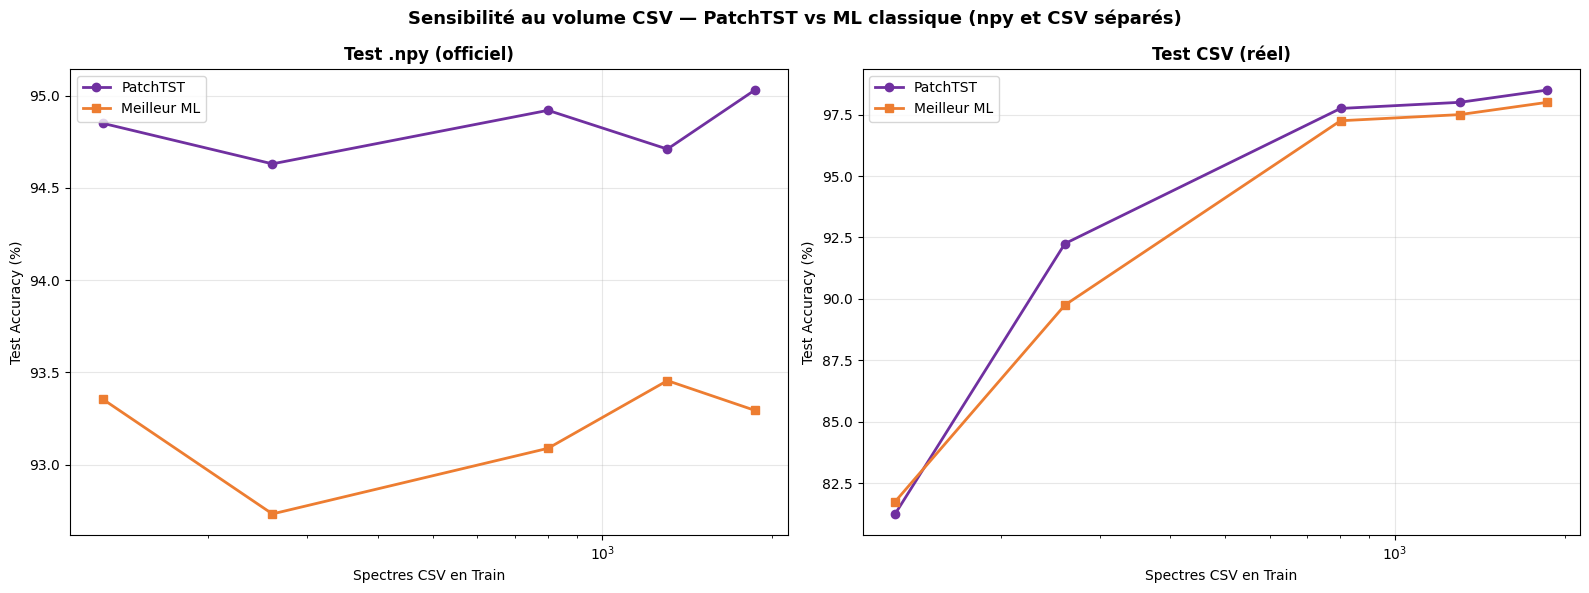

In [54]:
fractions = sorted(patchtst_results.keys(), reverse=True)
n_values = [patchtst_results[f]['n'] for f in fractions]

pt_npy = [patchtst_results[f]['acc_npy'] for f in fractions]
pt_csv = [patchtst_results[f]['acc_csv'] for f in fractions]
ml_npy = [rfgb_results_manual.get(f, {}).get('acc_npy') for f in fractions]
ml_csv = [rfgb_results_manual.get(f, {}).get('acc_csv') for f in fractions]

if any(v is None for v in ml_npy + ml_csv):
    print('⚠️  Complète rfgb_results_manual avec tous les runs avant de tracer.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    axes[0].plot(n_values, [v*100 for v in pt_npy], marker='o', linewidth=2, label='PatchTST', color='#7030A0')
    axes[0].plot(n_values, [v*100 for v in ml_npy], marker='s', linewidth=2, label='Meilleur ML', color='#ED7D31')
    axes[0].set_xscale('log'); axes[0].set_xlabel('Spectres CSV en Train')
    axes[0].set_ylabel('Test Accuracy (%)'); axes[0].set_title('Test .npy (officiel)', fontweight='bold')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(n_values, [v*100 for v in pt_csv], marker='o', linewidth=2, label='PatchTST', color='#7030A0')
    axes[1].plot(n_values, [v*100 for v in ml_csv], marker='s', linewidth=2, label='Meilleur ML', color='#ED7D31')
    axes[1].set_xscale('log'); axes[1].set_xlabel('Spectres CSV en Train')
    axes[1].set_ylabel('Test Accuracy (%)'); axes[1].set_title('Test CSV (réel)', fontweight='bold')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle('Sensibilité au volume CSV — PatchTST vs ML classique (npy et CSV séparés)',
                 fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(HOME, 'comparison_csv_sensitivity_both.png'), dpi=150, bbox_inches='tight')
    plt.show()